# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [228]:
import astropy.units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [231]:
speed = 60 * u.km / u.hour
speed_mps = speed.to(u.m / u.s)
print(f"{speed_mps.value:.2f} m/s")

16.67 m/s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [234]:
# The Julian calendar has a leap year every 4 years, resulting in an average year being about 365.25 days. 
# This drifts with respect to the season. 

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [239]:
# The Gregorian calendar leaves out three leap days every 400 years (years divisible by 100 are not leap years unless divisible by 400),
# making an average year 365.2425 days but keeping the calendar aligned with the seasons

From the astropy module `time` import `Time` in the cell below.

In [242]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [245]:
t_now = Time.now()

Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [248]:
t_landing = Time("1969-07-20 20:17:00", format="iso", scale="utc")

What historically happened at this date and time?

In [251]:
# The apollo 11 moon landing. It was the first time any human being has set foot on the moon. 

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [257]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [260]:
coord_icrs = SkyCoord(ra=15*u.deg, dec=-20*u.deg, frame="icrs")

Convert the object's coordinates from ICSRS to **Galactic**.

In [263]:
coord_gal = coord_icrs.galactic

Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [266]:
campbell = EarthLocation(lat=37.872*u.deg, lon=-122.257*u.deg, height=30*u.m)
altaz_frame = AltAz(obstime=Time.now(), location=campbell)
coord_altaz = coord_icrs.transform_to(altaz_frame)

## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [269]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [272]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [275]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [278]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [281]:
hdul = fits.open(image_file)
hdul.info()
print(hdul[0])
print(hdul[1])

Filename: C:\Users\jonat\.astropy\cache\download\url\ff6e0b93871033c68022ca026a956d87\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [284]:
data = hdul[0].data
print(np.max(data))

22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [287]:
print(np.min(data))

3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [290]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [293]:
names  = ["Sirius", "Betelgeuse", "Polaris"]
mags   = [-1.46,  0.42,        1.97]
types  = ["A1V",  "M2Iab",      "F7Ib"]

stars = Table([names, mags, types], names=("name", "magnitude", "spectral_type"))

Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [296]:
stars.write("my_stars.fits", format="fits", overwrite=True)

Read and print the table in the cell below from the `.fits` file you made.

In [299]:
stars_in = Table.read("my_stars.fits", format="fits")
stars_in.pprint()

   name    magnitude spectral_type
---------- --------- -------------
    Sirius     -1.46           A1V
Betelgeuse      0.42         M2Iab
   Polaris      1.97          F7Ib


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [302]:
# An H-R diagram plots the star's absolute magnitude versus their spectral type. 
# It has the chance to reveal interesting physical properties like temperature and luminosity

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [77]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [83]:
df = pd.read_csv(
    "cluster_data.tsv",
    skiprows=44,
    sep=";",
    header=None,
    index_col=0,
    names=["HIP", "Vmag", "Plx", "B-V", "SpType"],
    skipfooter=1,
    engine="python"
)

Display the first few rows of the data.

In [85]:
df.head()

,Vmag,Plx,B-V,SpType
HIP,,,,
10,8.59,10.76,0.489,F6V
11,7.34,4.29,0.081,A2
12,8.43,4.06,1.484,K4III
13,8.80,3.49,1.128,K0III
14,7.25,5.11,1.200,K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [173]:
df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

C:\Users\jonat\AppData\Local\Temp\ipykernel_33088\395354793.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [176]:
df_clean = df.dropna()

Run the cell below. We are converting the datatypes in the columns to floats.

In [179]:
# While running this cell, I kept getting the error: could not convert string to float: '       '
# No matter what I tried, I couldn't fix the error so this is ChatGPT's solution. I thought
# using ChatGPT here was fine since I was only supposed to run this cell anyway, not write any code. 
mask = (
    df_clean['Vmag'].str.strip().astype(bool) &
    df_clean['Plx'].str.strip().astype(bool) &
    df_clean['B-V'].str.strip().astype(bool)
)

# 2. Apply the mask to drop the bad rows
df_clean = df_clean[mask]

# 3. Now convert them in place to float, exactly as before
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# 4. Finally, you can safely describe
print(df_clean[['Vmag', 'Plx', 'B-V']].describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [184]:
# C:\Users\jonat\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
#  result = getattr(ufunc, method)(*inputs, **kwargs)
# C:\Users\jonat\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
#  result = getattr(ufunc, method)(*inputs, **kwargs) 

# ABOVE IS THE ERROR MESSAGE I KEPT GETTING WHEN RUNNING THIS CELL. No matter what I tried, I couldn't fix the error so this is ChatGPT's solution. 
# I thought using ChatGPT here was fine since I was only supposed to run this cell anyway, not write any code. 
df_clean['Vmag'] = pd.to_numeric(df_clean['Vmag'], errors='coerce')
df_clean['Plx'] = pd.to_numeric(df_clean['Plx'], errors='coerce')
df_clean = df_clean.dropna(subset=['Vmag','Plx'])
df_clean = df_clean[df_clean['Plx'] > 0]
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


Describe what the cell above is doing. 

In [192]:
# This cell takes each stars Vmag and its Plx and converts parallax to parsecs by dividing by 1000 then using
# the formula to return the absolute magnitude. 

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [195]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B9' 'M0' 'F8' 'M1'
 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2' 'A5'
 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'B5' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'F1' 'K6' 'O5' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [198]:
# Hottest stars: O
# Coldest stars: M

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [201]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [204]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

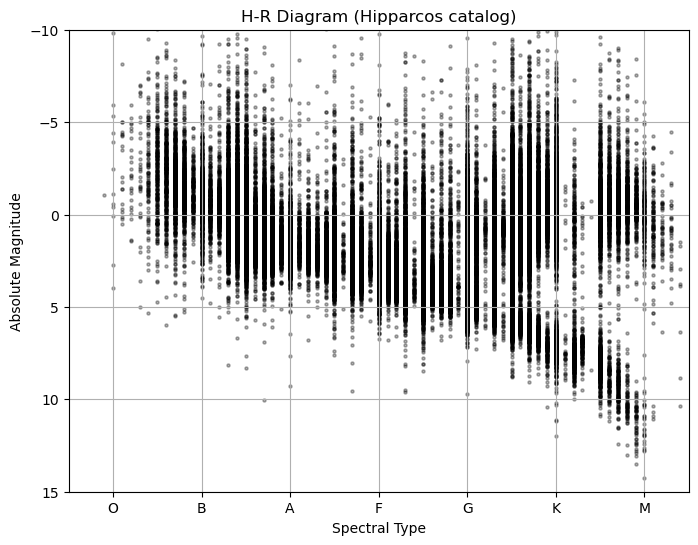

In [207]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_clean["SpType2"].apply(lambda x: int(x[1]) + {"O":0,"B":10,"A":20,"F":30,"G":40,"K":50,"M":60}[x[0]]),
    df_clean["M_V"],
    s=5, alpha=0.3, c="k"
)
plt.xlim(0, 70)
plt.ylim(15, -10)
plt.xticks(range(5, 75, 10), ["O","B","A","F","G","K","M"])
plt.xlabel("Spectral Type")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Hipparcos catalog)")
plt.grid(True)
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

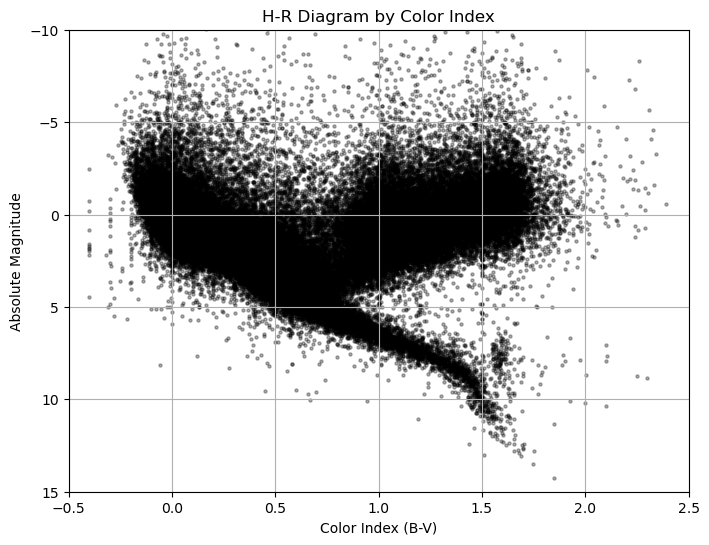

In [209]:
plt.figure(figsize=(8,6))
plt.scatter(df_clean["B-V"], df_clean["M_V"], s=5, alpha=0.3, c="k")
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram by Color Index")
plt.grid(True)
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

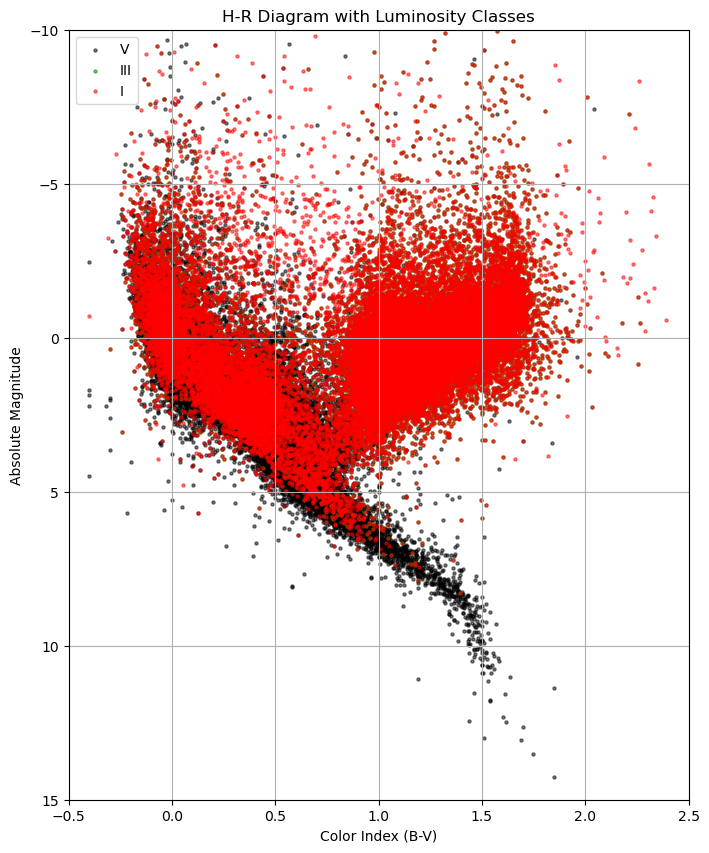

In [212]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

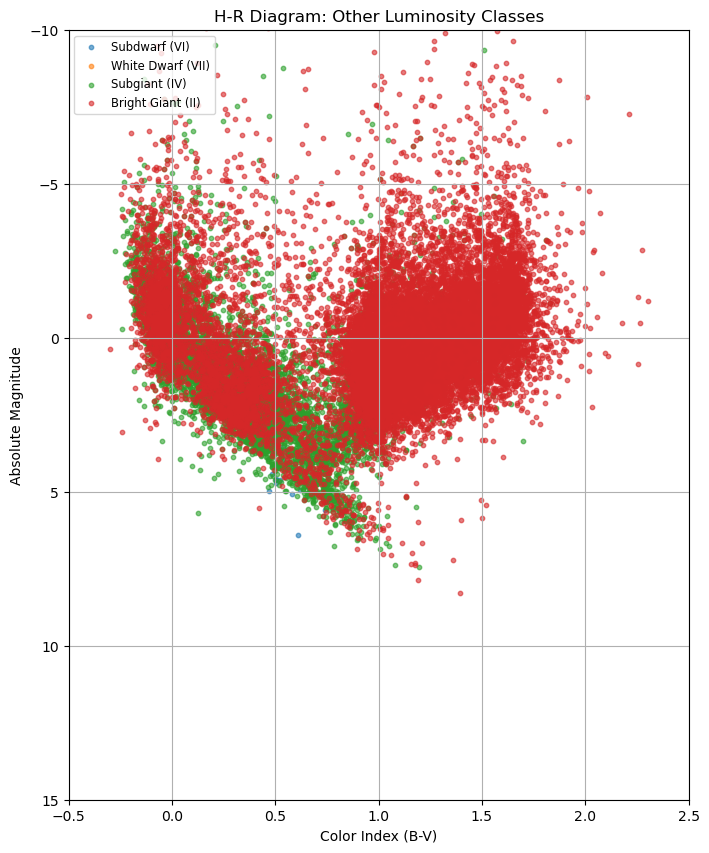

In [215]:
classes = [
    ("VI", "Subdwarf"),
    ("VII", "White Dwarf"),
    ("IV", "Subgiant"),
    ("II", "Bright Giant")
]

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram: Other Luminosity Classes")

for label, name in classes:
    mask = df_clean["SpType"].str.contains(label, na=False)
    plt.scatter(
        df_clean[mask]["B-V"],
        df_clean[mask]["M_V"],
        s=10, alpha=0.6,
        label=f"{name} ({label})"
    )

plt.legend(loc="upper left", fontsize="small")
plt.show()

Submit your FITS file and this notebook to Gradescope!